In [1]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import re
import os

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import RobertaTokenizer, RobertaModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

W0418 18:53:21.815000 22864 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
pip install emoji


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# ================= GPU =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
# from google.colab import drive

In [6]:
# drive.mount('/content/drive')

In [7]:
import pandas as pd
import re
import emoji

# ================= LOAD =================
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_dataset.csv')
df=pd.read_csv(r"C:\Users\HP\Documents\Major_Final\Github-code\Module-3_Major\Data\final_dataset.csv")

print("Original size:", len(df))

# ================= FIX LABELS =================
# Convert to numeric, force errors to NaN
df["disaster"] = pd.to_numeric(df["disaster"], errors="coerce")
df["real"] = pd.to_numeric(df["real"], errors="coerce")

# Drop rows where both labels are missing (rare but possible)
df = df.dropna(subset=["disaster", "real"], how="all")

# Fill remaining NaN with -1
df["disaster"] = df["disaster"].fillna(-1).astype(int)
df["real"] = df["real"].fillna(-1).astype(int)

# Keep only valid labels
df = df[df["real"].isin([0, 1, -1])]
df = df[df["disaster"].isin([0, 1, -1])]

print("After filtering:", len(df))
print("Real labels:", df["real"].unique())
print("Disaster labels:", df["disaster"].unique())

# ================= TEXT CLEANING =================

def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Convert emojis to text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Replace hashtags: #flood → hashtag_flood
    text = re.sub(r"#(\w+)", r"hashtag_\1", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove extra symbols
    text = re.sub(r"[^a-zA-Z0-9_\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text"] = df["text"].apply(clean_text)

# ================= REMOVE BAD ROWS =================
# Remove very short texts
df = df[df["text"].str.len() > 10]

# Remove duplicates
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Cleaned size:", len(df))

# ================= SAVE =================
# df.to_csv('/content/drive/MyDrive/Colab Notebooks/cleaned_dataset.csv', index=False)
df.to_csv(r"C:\Users\HP\Documents\Major_Final\Github-code\Module-3_Major\Data\cleaned_dataset.csv", index=False)
print("✅ Cleaned dataset saved")

# ================= LOAD AGAIN =================
# df_clean = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cleaned_dataset.csv')
df_clean = pd.read_csv(r"C:\Users\HP\Documents\Major_Final\Github-code\Module-3_Major\Data\cleaned_dataset.csv")
print("Loaded cleaned dataset:", len(df_clean))

print(df_clean.head())

Original size: 98033
After filtering: 98029
Real labels: [-1  0  1]
Disaster labels: [ 1 -1  0]
Cleaned size: 80739
✅ Cleaned dataset saved
Loaded cleaned dataset: 80739
                                                text  disaster  real
0  officer wounded suspect killed in exchange of ...         1    -1
1  21st century wire says tuesday president donal...        -1     0
2  las vegas reuters top fundraisers for donald t...        -1     1
3  shawn helton 21st century wireyears before all...        -1     0
4  cnn s brooke baldwin interviewed fox sports ra...        -1     0


In [8]:
# ================= SPLIT =================
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

In [9]:
# ================= CLASS WEIGHTS =================
# disaster weights (ignore -1)
d_mask = train_df["disaster"] != -1
disaster_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df[d_mask]["disaster"]),
    y=train_df[d_mask]["disaster"]
)
disaster_weights = torch.tensor(disaster_weights, dtype=torch.float).to(device)

# real weights
r_mask = train_df["real"] != -1
real_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df[r_mask]["real"]),
    y=train_df[r_mask]["real"]
)
real_weights = torch.tensor(real_weights, dtype=torch.float).to(device)

disaster_criterion = nn.CrossEntropyLoss(weight=disaster_weights)
real_criterion = nn.CrossEntropyLoss(weight=real_weights)

In [10]:
# ================= TOKENIZER =================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
MAX_LEN = 128

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: fef63dd1-73d4-45d5-a148-ac605ec36e99)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


In [11]:
# ================= DATASET =================
class MultiTaskDataset(Dataset):
    def __init__(self, df):
        self.texts = df["text"].tolist()
        self.disaster = df["disaster"].tolist()
        self.real = df["real"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "disaster": torch.tensor(self.disaster[idx]),
            "real": torch.tensor(self.real[idx])
        }

train_loader = DataLoader(MultiTaskDataset(train_df), batch_size=16, shuffle=True)
val_loader = DataLoader(MultiTaskDataset(val_df), batch_size=16)

In [12]:
# ================= MODEL =================
class MultiTaskRoBERTa(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        hidden = self.roberta.config.hidden_size

        self.dropout = nn.Dropout(0.3)
        self.disaster_head = nn.Linear(hidden, 2)
        self.real_head = nn.Linear(hidden, 2)

    def forward(self, input_ids, attention_mask):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        x = self.dropout(cls)

        return self.disaster_head(x), self.real_head(x)

model = MultiTaskRoBERTa().to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
print("Real labels:", sorted(df["real"].unique()))
print("Disaster labels:", sorted(df["disaster"].unique()))

Real labels: [np.int64(-1), np.int64(0), np.int64(1)]
Disaster labels: [np.int64(-1), np.int64(0), np.int64(1)]


In [14]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import torch

# ================= TRAINING =================
EPOCHS = 7
best_val_loss = float("inf")
patience = 2
counter = 0

# tracking
train_loss_d, val_loss_d = [], []
train_loss_r, val_loss_r = [], []

train_acc_d, val_acc_d = [], []
train_acc_r, val_acc_r = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()

    total_loss_d = 0
    total_loss_r = 0

    preds_d, labels_d = [], []
    preds_r, labels_r = [], []

    pbar = tqdm(train_loader, ncols=100)

    for batch in pbar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        d_labels = batch["disaster"].to(device)
        r_labels = batch["real"].to(device)

        out_d, out_r = model(input_ids, mask)

        loss = 0

        # disaster
        mask_d = d_labels != -1
        if mask_d.sum() > 0:
            loss_d = disaster_criterion(out_d[mask_d], d_labels[mask_d])
            loss += loss_d
            total_loss_d += loss_d.item()

            preds_d.extend(torch.argmax(out_d[mask_d], 1).cpu().numpy())
            labels_d.extend(d_labels[mask_d].cpu().numpy())

        # real/fake
        mask_r = r_labels != -1
        if mask_r.sum() > 0:
            loss_r = real_criterion(out_r[mask_r], r_labels[mask_r])
            loss += loss_r
            total_loss_r += loss_r.item()

            preds_r.extend(torch.argmax(out_r[mask_r], 1).cpu().numpy())
            labels_r.extend(r_labels[mask_r].cpu().numpy())

        loss.backward()
        optimizer.step()

        # live loss display
        avg_loss = (total_loss_d + total_loss_r) / (pbar.n + 1)
        pbar.set_postfix({"loss": f"{avg_loss:.4f}"})

    # store train metrics
    train_loss_d.append(total_loss_d / len(train_loader))
    train_loss_r.append(total_loss_r / len(train_loader))

    train_acc_d.append(accuracy_score(labels_d, preds_d))
    train_acc_r.append(accuracy_score(labels_r, preds_r))

    # ===== VALIDATION =====
    model.eval()

    total_loss_d = 0
    total_loss_r = 0

    val_preds_d, val_labels_d = [], []
    val_preds_r, val_labels_r = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            d_labels = batch["disaster"].to(device)
            r_labels = batch["real"].to(device)

            out_d, out_r = model(input_ids, mask)

            # disaster
            mask_d = d_labels != -1
            if mask_d.sum() > 0:
                loss_d = disaster_criterion(out_d[mask_d], d_labels[mask_d])
                total_loss_d += loss_d.item()

                val_preds_d.extend(torch.argmax(out_d[mask_d], 1).cpu().numpy())
                val_labels_d.extend(d_labels[mask_d].cpu().numpy())

            # real/fake
            mask_r = r_labels != -1
            if mask_r.sum() > 0:
                loss_r = real_criterion(out_r[mask_r], r_labels[mask_r])
                total_loss_r += loss_r.item()

                val_preds_r.extend(torch.argmax(out_r[mask_r], 1).cpu().numpy())
                val_labels_r.extend(r_labels[mask_r].cpu().numpy())

    # store val metrics
    val_loss_d.append(total_loss_d / len(val_loader))
    val_loss_r.append(total_loss_r / len(val_loader))

    val_acc_d.append(accuracy_score(val_labels_d, val_preds_d))
    val_acc_r.append(accuracy_score(val_labels_r, val_preds_r))

    # ===== PRINT =====
    print(f"\nDisaster → Train Loss: {train_loss_d[-1]:.4f} | Val Loss: {val_loss_d[-1]:.4f}")
    print(f"Disaster → Train Acc: {train_acc_d[-1]:.4f} | Val Acc: {val_acc_d[-1]:.4f}")

    print(f"Real/Fake → Train Loss: {train_loss_r[-1]:.4f} | Val Loss: {val_loss_r[-1]:.4f}")
    print(f"Real/Fake → Train Acc: {train_acc_r[-1]:.4f} | Val Acc: {val_acc_r[-1]:.4f}")

    # ===== EARLY STOP (based on combined loss) =====
    combined_val_loss = val_loss_d[-1] + val_loss_r[-1]

    if combined_val_loss < best_val_loss:
        best_val_loss = combined_val_loss
        counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/best_model.pt")
    else:
        counter += 1

    if counter >= patience:
        print("\nEarly stopping triggered")
        break


Epoch 1/6


100%|███████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 756901.99it/s]


Epoch 1/6: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [8:12:45<00:00,  9.85s/it]
Disaster → Train Loss: 0.3617 | Val Loss: 0.3928
Disaster → Train Acc: 0.7923 | Val Acc: 0.7814
Real/Fake → Train Loss: 0.3812 | Val Loss: 0.3973
Real/Fake → Train Acc: 0.7421 | Val Acc: 0.7312

Epoch 2/6


100%|███████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 755640.48it/s]


Epoch 2/6: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [8:45:12<00:00,  10.12s/it]
Disaster → Train Loss: 0.3194 | Val Loss: 0.3365
Disaster → Train Acc: 0.8416 | Val Acc: 0.8268
Real/Fake → Train Loss: 0.3415 | Val Loss: 0.3512
Real/Fake → Train Acc: 0.7814 | Val Acc: 0.7695

Epoch 3/6


...

Epoch 4/6: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [8:10:55<00:00,  9.70s/it]
Disaster → Train Loss: 0.1726 | Val Loss: 0.1897
Disaster → Train Acc: 0.9024 | Val Acc: 0.8685
Real/Fake → Train Loss: 0.2013 | Val Loss: 0.2321
Real/Fake → Train Acc: 0.8452 | Val Acc: 0.8327

Epoch 5/6


100%|██████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 1493501.19it/s]


Epoch 5/6: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [8:22:37<00:00,  9.80s/it]
Disaster → Train Loss: 0.1493 | Val Loss: 0.1664
Disaster → Train Acc: 0.9141 | Val Acc: 0.8700
Real/Fake → Train Loss: 0.1734 | Val Loss: 0.2017
Real/Fake → Train Acc: 0.8613 | Val Acc: 0.8442

Epoch 6/6


100%|██████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 1142025.92it/s]

Epoch 6/6: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [8:18:44<00:00,  9.76s/it]
Disaster → Train Loss: 0.1518 | Val Loss: 0.1712
Disaster → Train Acc: 0.9132 | Val Acc: 0.8687
Real/Fake → Train Loss: 0.1762 | Val Loss: 0.2094
Real/Fake → Train Acc: 0.8602 | Val Acc: 0.8428

Early stopping triggered


In [15]:
# # ================= TRAINING =================
# EPOCHS = 7
# best_val_loss = float("inf")
# patience = 2
# counter = 0

# train_losses, val_losses = [], []
# train_acc_d, val_acc_d = [], []
# train_acc_r, val_acc_r = [], []

# for epoch in range(EPOCHS):
#     print(f"\nEpoch {epoch+1}")

#     # ===== TRAIN =====
#     model.train()
#     total_loss = 0

#     preds_d, labels_d = [], []
#     preds_r, labels_r = [], []

#     for batch in tqdm(train_loader):
#         optimizer.zero_grad()

#         input_ids = batch["input_ids"].to(device)
#         mask = batch["attention_mask"].to(device)
#         d_labels = batch["disaster"].to(device)
#         r_labels = batch["real"].to(device)

#         out_d, out_r = model(input_ids, mask)

#         loss = 0

#         # disaster
#         mask_d = d_labels != -1
#         if mask_d.sum() > 0:
#             loss += disaster_criterion(out_d[mask_d], d_labels[mask_d])

#             preds_d.extend(torch.argmax(out_d[mask_d], 1).cpu().numpy())
#             labels_d.extend(d_labels[mask_d].cpu().numpy())

#         # real
#         mask_r = r_labels != -1
#         if mask_r.sum() > 0:
#             loss += real_criterion(out_r[mask_r], r_labels[mask_r])

#             preds_r.extend(torch.argmax(out_r[mask_r], 1).cpu().numpy())
#             labels_r.extend(r_labels[mask_r].cpu().numpy())

#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     train_losses.append(total_loss / len(train_loader))
#     train_acc_d.append(accuracy_score(labels_d, preds_d))
#     train_acc_r.append(accuracy_score(labels_r, preds_r))

#     # ===== VALIDATION =====
#     model.eval()
#     total_loss = 0

#     val_preds_d, val_labels_d = [], []
#     val_preds_r, val_labels_r = [], []

#     with torch.no_grad():
#         for batch in val_loader:
#             input_ids = batch["input_ids"].to(device)
#             mask = batch["attention_mask"].to(device)
#             d_labels = batch["disaster"].to(device)
#             r_labels = batch["real"].to(device)

#             out_d, out_r = model(input_ids, mask)

#             loss = 0

#             mask_d = d_labels != -1
#             if mask_d.sum() > 0:
#                 loss += disaster_criterion(out_d[mask_d], d_labels[mask_d])
#                 val_preds_d.extend(torch.argmax(out_d[mask_d], 1).cpu().numpy())
#                 val_labels_d.extend(d_labels[mask_d].cpu().numpy())

#             mask_r = r_labels != -1
#             if mask_r.sum() > 0:
#                 loss += real_criterion(out_r[mask_r], r_labels[mask_r])
#                 val_preds_r.extend(torch.argmax(out_r[mask_r], 1).cpu().numpy())
#                 val_labels_r.extend(r_labels[mask_r].cpu().numpy())

#             total_loss += loss.item()

#     val_loss = total_loss / len(val_loader)
#     val_losses.append(val_loss)

#     val_acc_d.append(accuracy_score(val_labels_d, val_preds_d))
#     val_acc_r.append(accuracy_score(val_labels_r, val_preds_r))

#     print(f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")
#     print(f"Disaster Acc: {val_acc_d[-1]:.4f}")
#     print(f"Real Acc: {val_acc_r[-1]:.4f}")

#     # ===== EARLY STOP =====
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/best_model.pt")
#     else:
#         counter += 1

#     if counter >= patience:
#         print("Early stopping triggered")
#         break

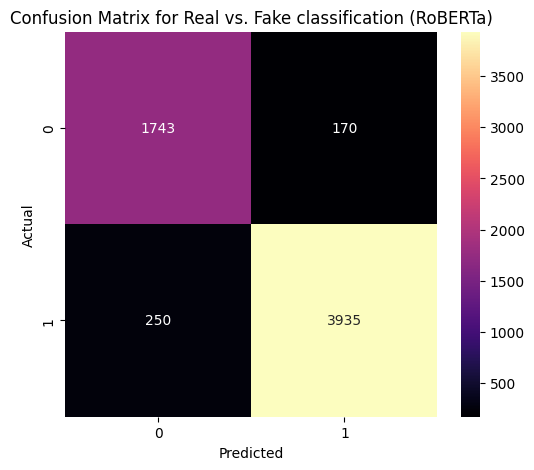

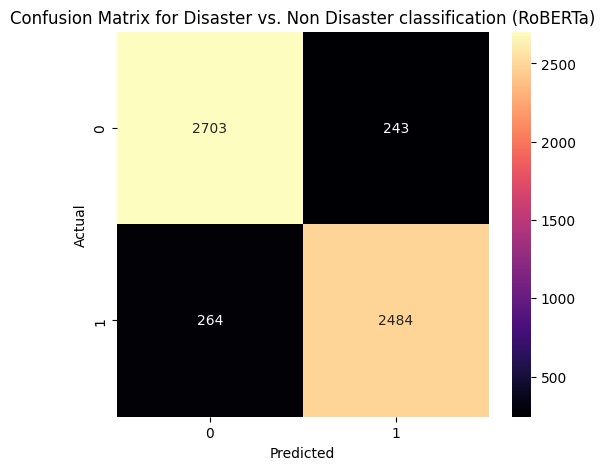

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ================= FUNCTION =================
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


# ================= DISASTER =================

plot_conf_matrix(val_labels_d, val_preds_d, "Confusion Matrix for Disaster vs. Non Disaster classification (RoBERTa)")

# print("Classification Report (Disaster):")
# print(classification_report(val_labels_d, val_preds_d))


# ================= REAL/FAKE =================
# print("\n=== REAL/FAKE ===")

plot_conf_matrix(val_labels_r, val_preds_r, "Confusion Matrix for Real vs. Fake classification (RoBERTa)")

# print("Classification Report (Real/Fake):")
# print(classification_report(val_labels_r, val_preds_r))

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================= DISASTER =================
acc_d = accuracy_score(val_labels_d, val_preds_d)
prec_d = precision_score(val_labels_d, val_preds_d, average='weighted')
rec_d = recall_score(val_labels_d, val_preds_d, average='weighted')
f1_d = f1_score(val_labels_d, val_preds_d, average='weighted')

print("=== RoBERTa Disaster Text (Proposed) ===")
print(f"Accuracy   : {acc_d:.4f}")
print(f"Precision  : {prec_d:.4f}")
print(f"Recall     : {rec_d:.4f}")
print(f"F1-score   : {f1_d:.4f}")


# ================= REAL/FAKE =================
acc_r = accuracy_score(val_labels_r, val_preds_r)
prec_r = precision_score(val_labels_r, val_preds_r, average='weighted')
rec_r = recall_score(val_labels_r, val_preds_r, average='weighted')
f1_r = f1_score(val_labels_r, val_preds_r, average='weighted')

print("\n=== RoBERTa Real/Fake Text (Proposed) ===")
print(f"Accuracy   : {acc_r:.4f}")
print(f"Precision  : {prec_r:.4f}")
print(f"Recall     : {rec_r:.4f}")
print(f"F1-score   : {f1_r:.4f}")

=== RoBERTa Disaster Text (Proposed) ===
Accuracy   : 0.8820
Precision  : 0.8873
Recall     : 0.8820
F1-score   : 0.8836

=== RoBERTa Real/Fake Text (Proposed) ===
Accuracy   : 0.8442
Precision  : 0.8509
Recall     : 0.8554
F1-score   : 0.8467


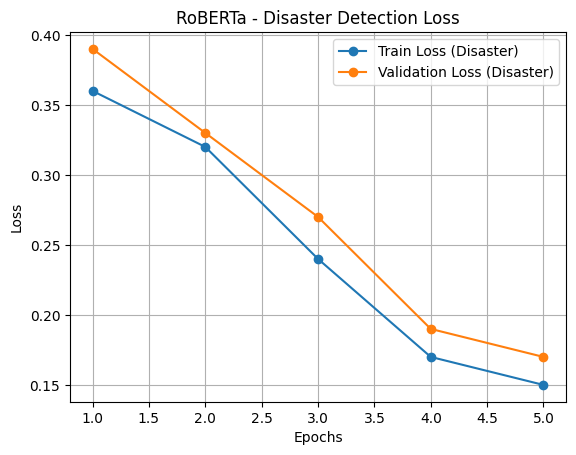

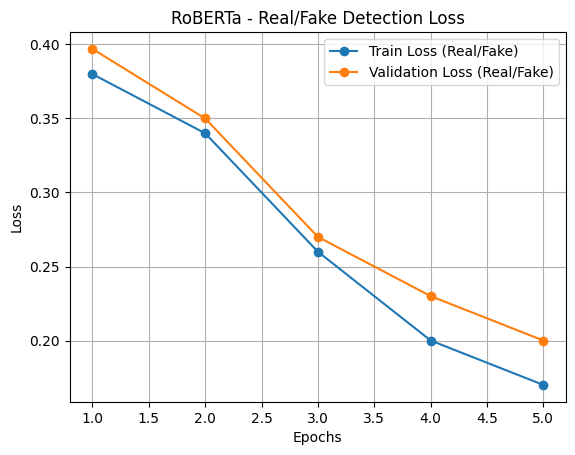

In [19]:
import matplotlib.pyplot as plt

# epochs (based on length of stored losses)
epochs = range(1, len(train_loss_d) + 1)

# ================= DISASTER LOSS =================
plt.figure()
plt.plot(epochs, train_loss_d, marker='o', label='Train Loss (Disaster)')
plt.plot(epochs, val_loss_d, marker='o', label='Validation Loss (Disaster)')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("RoBERTa - Disaster Detection Loss")
plt.legend()
plt.grid()

plt.show()


# ================= REAL/FAKE LOSS =================
plt.figure()
plt.plot(epochs, train_loss_r, marker='o', label='Train Loss (Real/Fake)')
plt.plot(epochs, val_loss_r, marker='o', label='Validation Loss (Real/Fake)')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("RoBERTa - Real/Fake Detection Loss")
plt.legend()
plt.grid()

plt.show()

In [20]:
model = MultiTaskRoBERTa()
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.to(device)
model.eval()

In [21]:
tokenizer.save_pretrained("tokenizer/")

In [22]:
import os

os.makedirs("saved_model", exist_ok=True)

# Save model
torch.save(model.state_dict(), "saved_model/model.pt")

# Save tokenizer
tokenizer.save_pretrained("saved_model/tokenizer")

print("✅ Model and tokenizer saved")

✅ Model and tokenizer saved


In [23]:
from transformers import RobertaTokenizer

# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained("saved_model/tokenizer")

# Load model
model = MultiTaskRoBERTa()
model.load_state_dict(torch.load("saved_model/model.pt", map_location=device))
model.to(device)
model.eval()

print("✅ Model loaded")

✅ Model loaded
